# 🧠 Redes Neurais Artificiais para Controle e Automação

> **Curso:** Controle e Automação de Processos  
> **Tema:** Introdução a ANN

---

## Estrutura do Notebook

| Parte | Conteúdo |
|---|---|
| **Parte 1** | Fundamentos teóricos + implementação do zero (NumPy) |

<div align="center">
  <h2>🧠 Das Células aos Algoritmos: A Inspiração Biológica das Redes Neurais</h2>
</div>

A ideia de criar máquinas que "pensam" ou aprendem começou com a observação da máquina de processamento mais complexa que conhecemos: o cérebro humano. Na década de 1940, na época da concepção dessa ideia, o neurofisiologista Warren McCulloch e o matemático Walter Pitts (1943) propuseram o primeiro modelo matemático de um neurônio. Mais tarde, em 1958, Frank Rosenblatt expandiu esse conceito com o **Perceptron**, criando a base fundamental para as Redes Neurais Artificiais (RNAs) que usamos hoje no Deep Learning.

O objetivo deles não era replicar a biologia com perfeição anatômica, mas sim criar uma abstração matemática do seu mecanismo de processamento e transmissão de informações.

---

### 🔬 O Neurônio Biológico vs. 🤖 O Neurônio Artificial
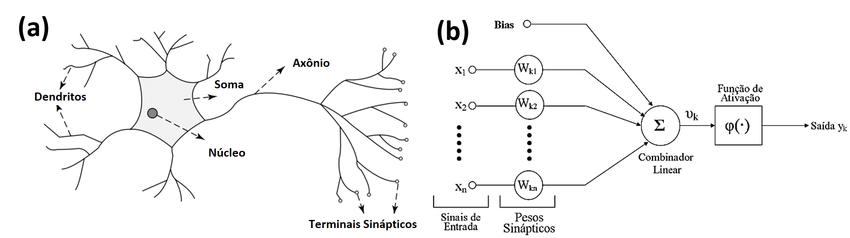
<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/1/10/Blausen_0657_MultipolarNeuron.png/400px-Blausen_0657_MultipolarNeuron.png" width="45%" alt="Neurônio Biológico">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/60/ArtificialNeuronModel_english.png/400px-ArtificialNeuronModel_english.png" width="45%" alt="Neurônio Artificial">
</p>

No cérebro, um neurônio recebe sinais elétricos de outros neurônios através de ramificações chamadas **dendritos**. Esses sinais viajam e se acumulam no **corpo celular** (soma). Se a carga elétrica total ultrapassar um certo limite (potencial de ação), o neurônio "dispara", enviando um impulso elétrico pelo **axônio** para os próximos neurônios através das **sinapses**.

O modelo artificial funciona de forma incrivelmente análoga:

1. **Entradas ($x_i$):** Representam os sinais vindos de outros neurônios ou dados do mundo real (Dendritos).
2. **Pesos ($w_i$):** Representam a força ou importância da conexão. O "aprendizado" da rede neural ocorre justamente ajustando esses pesos (Sinapses).
3. **Soma Ponderada ($\Sigma$):** O núcleo do neurônio multiplica cada entrada por seu respectivo peso e soma tudo, adicionando também um viés (*bias*, $b$). Isso simula o acúmulo de voltagem no Corpo Celular.
4. **Função de Ativação ($f$):** Decide se o neurônio artificial deve "disparar" ou não, baseando-se no resultado da soma matemática.
5. **Saída ($y$):** O sinal resultante que é passado adiante para a próxima camada da rede (Axônio).

### 📊 De Para: Biologia x Matemática

| Biologia (Cérebro Humano) | Matemática (Rede Neural Artificial) | Função Principal |
| :--- | :--- | :--- |
| **Dendritos** | Entradas ($x_1, x_2, ... x_n$) | Receber informações |
| **Sinapses** | Pesos ($w_1, w_2, ... w_n$) | Controlar a força e importância do sinal |
| **Corpo Celular (Soma)** | Soma Ponderada ($\sum x_i w_i + b$) | Agregar e processar os sinais recebidos |
| **Limiar de Disparo** | Função de Ativação ($f$) | Decidir se o sinal passa adiante |
| **Axônio** | Saída ($y$) | Transmitir o resultado processado |

<br>




---
# PARTE 1 — Fundamentos de Redes Neurais

## 1.1 O Neurônio Artificial

O neurônio artificial é inspirado no neurônio biológico. Ele recebe múltiplos sinais de entrada, pondera cada um com um **peso**, soma tudo (incluindo um **bias**) e passa o resultado por uma **função de ativação**.

### Equação do Neurônio

$$z = \sum_{i=1}^{n} w_i x_i + b = \mathbf{w}^T \mathbf{x} + b$$

$$y = f(z)$$

onde:
- $x_i$ são as entradas
- $w_i$ são os pesos (parâmetros aprendíveis)
- $b$ é o bias
- $f(\cdot)$ é a função de ativação

### Funções de Ativação Comuns

| Função | Fórmula | Intervalo | Uso típico |
|---|---|---|---|
| Sigmoid | $\sigma(z) = \frac{1}{1+e^{-z}}$ | $(0, 1)$ | Classificação binária |
| Tanh | $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$ | $(-1, 1)$ | Controle, RNNs |
| ReLU | $\text{ReLU}(z) = \max(0, z)$ | $[0, +\infty)$ | Camadas ocultas (deep learning) |
| Linear | $f(z) = z$ | $(-\infty, +\infty)$ | Saída de regressão |

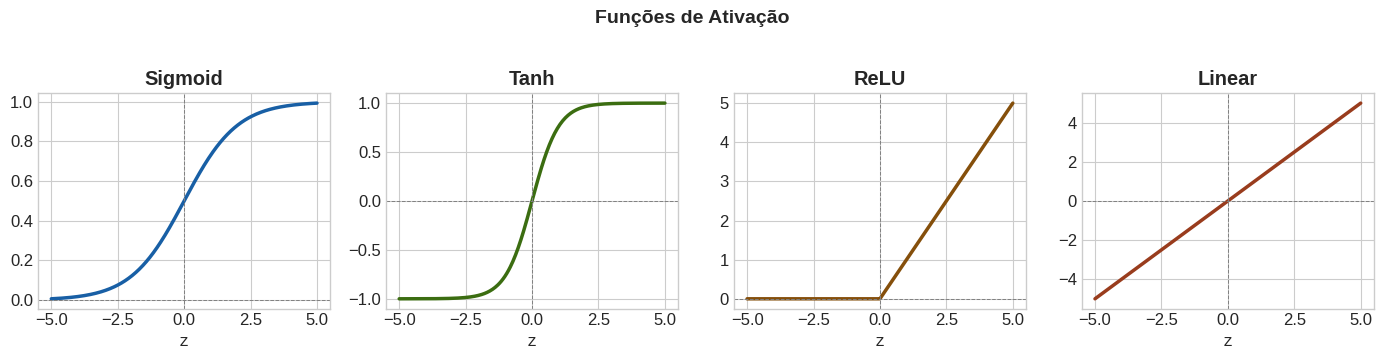

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 12

z = np.linspace(-5, 5, 300)

sigmoid = 1 / (1 + np.exp(-z))
tanh    = np.tanh(z)
relu    = np.maximum(0, z)
linear  = z

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
fns = [(sigmoid, 'Sigmoid', '#185FA5'),
       (tanh,    'Tanh',    '#3B6D11'),
       (relu,    'ReLU',    '#854F0B'),
       (linear,  'Linear',  '#993C1D')]

for ax, (fn, name, color) in zip(axes, fns):
    ax.plot(z, fn, color=color, lw=2.5)
    ax.axhline(0, color='gray', lw=0.7, ls='--')
    ax.axvline(0, color='gray', lw=0.7, ls='--')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('z')

plt.suptitle('Funções de Ativação', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 1.2 Multilayer Perceptron (MLP)
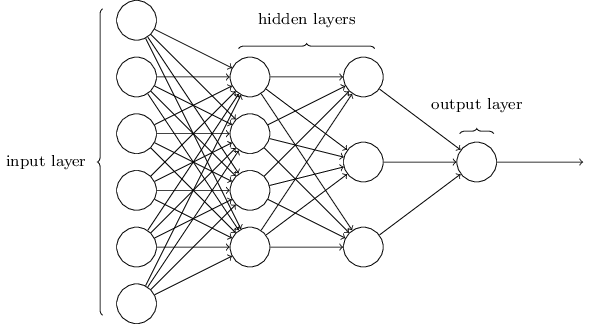

Uma **rede neural multicamadas** (MLP) empilha neurônios em camadas:

```
Entradas  →  [Camada Oculta 1]  →  [Camada Oculta 2]  →  Saída
  (x)            (h¹)                   (h²)              (ŷ)
```

Cada camada realiza:

$$\mathbf{h}^{(l)} = f\left(\mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}\right)$$

> **Teorema de Aproximação Universal:** Uma MLP com pelo menos uma camada oculta e função de ativação não-linear pode aproximar qualquer função contínua em um domínio compacto, desde que tenha neurônios suficientes.

## 1.3 Treinamento: Backpropagation + Gradient Descent

O objetivo é minimizar uma **função de perda** (loss). Para regressão, usamos o **MSE**:

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

O algoritmo de treinamento:

1. **Forward pass:** calcular $\hat{y}$ com os pesos atuais
2. **Calcular o loss:** $\mathcal{L}(y, \hat{y})$
3. **Backward pass:** calcular $\frac{\partial \mathcal{L}}{\partial \mathbf{W}}$ via regra da cadeia
4. **Atualizar pesos:** $\mathbf{W} \leftarrow \mathbf{W} - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{W}}$

onde $\eta$ é a **taxa de aprendizado** (learning rate).
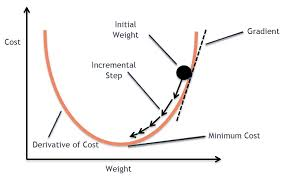

## Algoritmo de Treinamento — Rede Neural (MLP)

**Dados:** $N$ pares $(\mathbf{x}_i, y_i)$, taxa de aprendizado $\eta$, número de épocas $E$

**Objetivo:** encontrar pesos $\mathbf{W}^{(1)}, \mathbf{W}^{(2)}, \ldots$ que minimizam $\mathcal{L} = \frac{1}{N}\sum(y_i - \hat{y}_i)^2$

---

**Para cada época** $n = 1, 2, \ldots, E$:

1. Dado o conjunto $(\mathbf{X}, \mathbf{y})$

2. **Forward pass** — propagar a entrada camada a camada:

$$\mathbf{z}^{(l)} = \mathbf{W}^{(l)}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$$

$$\mathbf{a}^{(l)} = f\!\left(\mathbf{z}^{(l)}\right)$$

com $\mathbf{a}^{(0)} = \mathbf{X}$

3. **Calcular o erro (loss)**:

$$\mathcal{L}^{(n)} = \frac{1}{N}\sum_{i=1}^{N}\left(y_i - \hat{y}_i\right)^2$$

4. **Backward pass** — propagar o gradiente da saída para a entrada (regra da cadeia):

$$\boldsymbol{\delta}^{(L)} = \frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(L)}}$$

$$\boldsymbol{\delta}^{(l)} = \left(\mathbf{W}^{(l+1)T}\boldsymbol{\delta}^{(l+1)}\right) \odot f'\!\left(\mathbf{z}^{(l)}\right)$$

5. **Calcular os gradientes**:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}} = \boldsymbol{\delta}^{(l)}\,\mathbf{a}^{(l-1)T} \qquad \frac{\partial \mathcal{L}}{\partial \mathbf{b}^{(l)}} = \boldsymbol{\delta}^{(l)}$$

6. **Atualizar os pesos** (Gradient Descent):

$$\mathbf{W}^{(l)} \leftarrow \mathbf{W}^{(l)} - \eta\,\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}}$$

$$\mathbf{b}^{(l)} \leftarrow \mathbf{b}^{(l)} - \eta\,\frac{\partial \mathcal{L}}{\partial \mathbf{b}^{(l)}}$$

7. **Verificar convergência:** se $|\mathcal{L}^{(n)} - \mathcal{L}^{(n-1)}| < \varepsilon$, parar

---

> **Onde** $\odot$ é o produto elemento a elemento (Hadamard), $L$ é a camada de saída, e $f'$ é a derivada da função de ativação — para tanh: $f'(z) = 1 - \tanh^2(z)$, para ReLU: $f'(z) = \mathbf{1}[z > 0]$.

Loss final: 0.000202


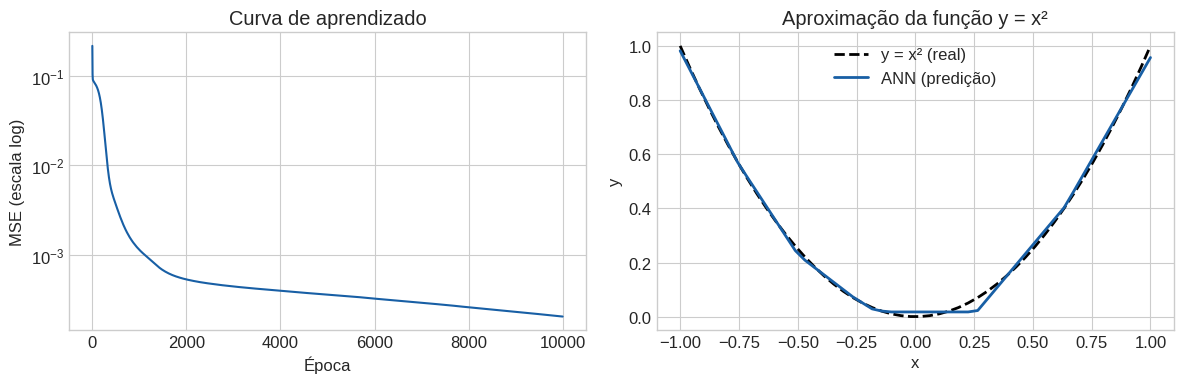

In [ ]:
# ============================================================
#  MLP DO ZERO com NumPy — Aprendendo y = x²
#  Rede: 1 entrada → 8 neurônios ocultos (ReLU) → 1 saída
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# --- Dataset ---
np.random.seed(42)
X = np.linspace(-1, 1, 200).reshape(-1, 1)
y = X ** 2


# --- Inicialização dos pesos ---
W1 = np.random.randn(1,16) * 0.1   # pesos camada 1
b1 = np.zeros((1, 16))               # bias camada 1
W2 = np.random.randn(16, 1) * 0.1   # pesos camada 2
b2 = np.zeros((1, 1))               # bias camada 2

# --- Funções auxiliares ---
def relu(z):        return np.maximum(0, z)
def relu_d(z):      return (z > 0).astype(float)
def tanh(z):       return np.tanh(z)
def tanh_d(z):     return 1 - np.tanh(z)**2   # derivada: 1 - tanh²(z)

# --- Treinamento ---
lr = 0.1
losses = []

for epoch in range(10000):
    # Forward pass
    z1   = X @ W1 + b1
    a1   = relu(z1)
    z2   = a1 @ W2 + b2
    yhat = z2                         # saída linear

    # Loss (MSE)
    loss = np.mean((y - yhat) ** 2)
    losses.append(loss)

    # Backward pass
    dL   = -2 * (y - yhat) / len(X)  # dL/dŷ
    dW2  = a1.T @ dL
    db2  = dL.sum(axis=0)
    da1  = dL @ W2.T
    dz1  = da1 * relu_d(z1)
    dW1  = X.T @ dz1
    db1  = dz1.sum(axis=0)
    '''
    # Backward pass
    dL   = -2 * (y - yhat) / len(X)
    dW2  = a1.T @ dL
    db2  = dL.sum(axis=0)
    da1  = dL @ W2.T
    dz1  = da1 * tanh_d(z1)      # ← derivada da tanh
    dW1  = X.T @ dz1
    db1  = dz1.sum(axis=0)'''

    # Atualização dos pesos
    W1 -= lr * dW1;  b1 -= lr * db1
    W2 -= lr * dW2;  b2 -= lr * db2

print(f"Loss final: {losses[-1]:.6f}")

# --- Visualização ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogy(losses, color='#185FA5', lw=1.5)
ax1.set_xlabel('Época'); ax1.set_ylabel('MSE (escala log)')
ax1.set_title('Curva de aprendizado')

X_test = np.linspace(-1, 1, 50).reshape(-1, 1)
yhat_test= relu(relu(X_test @ W1 + b1) @ W2 + b2)
ax2.plot(X_test, X_test**2, 'k--', lw=2, label='y = x² (real)')
ax2.plot(X_test, yhat_test, color='#185FA5', lw=2, label='ANN (predição)')
ax2.legend(); ax2.set_title('Aproximação da função y = x²')
ax2.set_xlabel('x'); ax2.set_ylabel('y')

plt.tight_layout()
plt.show()

## Equações Normais com Expansão de Features

### O problema

Queremos ajustar um modelo aos dados $(x_i, y_i)$ minimizando o erro quadrático total:

$$\min_{\mathbf{w}} \sum_{i=1}^{N} \left( y_i - \hat{y}_i \right)^2$$

A **regressão linear** resolve isso de forma fechada — mas só funciona quando o modelo é **linear nos parâmetros**:

$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \cdots$$

O problema é que $y = x^2$ é não-linear em $x$. Como aplicar equações normais aqui?

---

### A solução: Expansão de Features (Feature Expansion)

O truque é criar novas variáveis a partir de $x$, transformando um problema não-linear em $x$ em um problema **linear nos parâmetros** $\mathbf{w}$:

$$\hat{y} = w_0 \cdot 1 + w_1 \cdot x + w_2 \cdot x^2$$

Isso é não-linear em $x$, mas **linear em** $w_0, w_1, w_2$ — e é isso que importa para as equações normais.

Montamos a **matriz de design** $\Phi$ onde cada linha corresponde a uma amostra:

$$\Phi = \begin{bmatrix} 1 & x_1 & x_1^2 \\ 1 & x_2 & x_2^2 \\ \vdots & \vdots & \vdots \\ 1 & x_N & x_N^2 \end{bmatrix}$$

O problema de regressão vira então:

$$\min_{\mathbf{w}} \left\| \mathbf{y} - \Phi\mathbf{w} \right\|^2$$

---

### Dedução das Equações Normais

Expandindo o erro quadrático:

$$\mathcal{L}(\mathbf{w}) = (\mathbf{y} - \Phi\mathbf{w})^T(\mathbf{y} - \Phi\mathbf{w})$$

Derivando em relação a $\mathbf{w}$ e igualando a zero:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = -2\Phi^T(\mathbf{y} - \Phi\mathbf{w}) = 0$$

$$\Phi^T \Phi \, \mathbf{w} = \Phi^T \mathbf{y}$$

Isolando $\mathbf{w}$ (assumindo que $\Phi^T\Phi$ é invertível):

$$\boxed{\mathbf{w} = \left(\Phi^T \Phi\right)^{-1} \Phi^T \mathbf{y}}$$

Esta é a **solução exata e fechada** — não há iteração, não há learning rate, não há épocas.

---

### Comparação com a ANN

| Aspecto | Equações Normais | ANN (Backpropagation) |
|---|---|---|
| **Solução** | Fechada (uma operação) | Iterativa (épocas) |
| **Features** | Definidas manualmente | Aprendidas automaticamente |
| **Custo computacional** | $\mathcal{O}(p^3)$ — inversão de matriz | $\mathcal{O}(\text{épocas} \times N)$ |
| **Escalabilidade** | Ruim para muitas features | Boa para problemas grandes |
| **Não-linearidades complexas** | Exige saber quais features criar | Aprende sozinha |
| **Resultado para $y=x^2$** | MSE $\approx 10^{-32}$ (exato) | MSE $> 0$ (aproximado) |

> **Conclusão:** as equações normais são imbatíveis quando sabemos a estrutura do problema. A ANN é preferível quando a função verdadeira é desconhecida ou complexa demais para ser descrita por features manuais — que é exatamente o caso de sistemas dinâmicos não-lineares em controle de processos.

w₀ (bias) = -0.000000  → esperado: ~0
w₁ (x)   = -0.000000  → esperado: ~0
w₂ (x²)  = 1.000000  → esperado: ~1

MSE = 3.30e-32  (praticamente zero — solução exata)


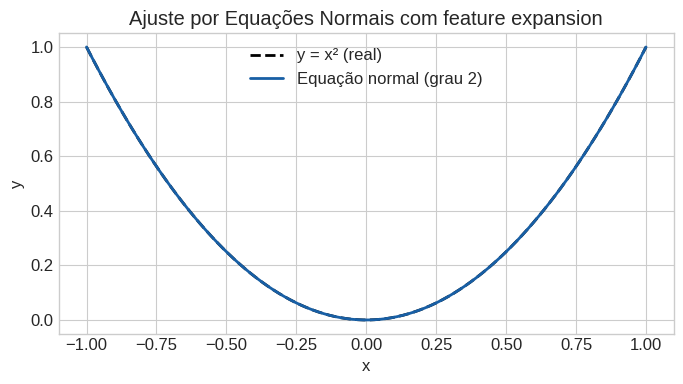

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.linspace(-1, 1, 100)
y = X ** 2

# ── Feature expansion: [1, x, x²] ──────────────────────────────────────────
# Cada linha vira [1,  x_i,  x_i²]
Phi = np.column_stack([np.ones_like(X), X, X**2])

# ── Equação normal: w = (PhiT @ Phi)^-1 @ PhiT @ y ─────────────────────────
w = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ y

print(f"w₀ (bias) = {w[0]:.6f}  → esperado: ~0")
print(f"w₁ (x)   = {w[1]:.6f}  → esperado: ~0")
print(f"w₂ (x²)  = {w[2]:.6f}  → esperado: ~1")

# Predição
y_pred = Phi @ w
mse = np.mean((y - y_pred)**2)
print(f"\nMSE = {mse:.2e}  (praticamente zero — solução exata)")

# Visualização
plt.figure(figsize=(7, 4))
plt.plot(X, y,      'k--', lw=2,   label='y = x² (real)')
plt.plot(X, y_pred, color='#185FA5', lw=2, label='Equação normal (grau 2)')
plt.title('Ajuste por Equações Normais com feature expansion')
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.tight_layout(); plt.show()

---
# PARTE 2 — Identificação de Sistemas Dinâmicos com NARX

## 2.1 O que é um modelo NARX?

**NARX** = *Nonlinear AutoRegressive with eXogenous inputs*

A ideia é usar uma ANN para aprender o modelo de um processo a partir de dados:

$$\hat{y}(k+1) = f\bigl(y(k),\, y(k-1),\, \ldots,\, u(k),\, u(k-1),\, \ldots\bigr)$$

Ou seja: dado o histórico de saídas e entradas, a rede prevê o próximo valor da saída.

### Por que isso é útil em controle?

- Sistemas reais frequentemente têm **dinâmica não-linear** difícil de modelar analiticamente
- O modelo NARX pode ser embutido em um **controlador preditivo (MPC neural)**
- Serve como base para **simulação off-line** e projeto do controlador

## 2.2 Planta-exemplo: Sistema de 1ª ordem

$$y(k+1) = 0.8\, y(k) + 0.2\, u(k) + \epsilon$$

Vamos gerar dados com entrada aleatória e treinar a ANN para identificar esse modelo.

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
#  IDENTIFICAÇÃO DE SISTEMA COM NARX (Scikit-learn)
# ============================================================

# --- Geração de dados do sistema ---
np.random.seed(0)
N  = 600
u  = np.random.uniform(-1, 1, N)     # entrada aleatória (PRBS simplificado)
y  = np.zeros(N)

for k in range(1, N):
    y[k] = 0.8 * y[k-1] + 0.2 * u[k-1]

# --- Montar dataset NARX: entradas = [y(k), u(k)], saída = y(k+1) ---
atrasos = 2   # número de atrasos (ordem do modelo)

X_narx = np.column_stack([
    y[atrasos-1:-1],   # y(k)
    y[atrasos-2:-2] if atrasos > 1 else np.zeros(N - atrasos),  # y(k-1)
    u[atrasos-1:-1],   # u(k)
    u[atrasos-2:-2] if atrasos > 1 else np.zeros(N - atrasos),  # u(k-1)
])
Y_narx = y[atrasos:]

# --- Dividir treino/teste ---
split = int(0.8 * len(Y_narx))
X_tr, X_te = X_narx[:split], X_narx[split:]
Y_tr, Y_te = Y_narx[:split], Y_narx[split:]

# --- Normalização ---
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

# --- Treinar MLP ---
mlp_id = MLPRegressor(
    hidden_layer_sizes=(16, 8),
    activation='tanh',
    max_iter=2000,
    learning_rate_init=0.005,
    random_state=42,
    verbose=False
)
mlp_id.fit(X_tr_sc, Y_tr)

Y_pred_tr = mlp_id.predict(X_tr_sc)
Y_pred_te = mlp_id.predict(X_te_sc)

print(f"R² treino: {r2_score(Y_tr, Y_pred_tr):.4f}")
print(f"R² teste:  {r2_score(Y_te, Y_pred_te):.4f}")

# --- Visualização ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(Y_tr, 'k', lw=1.2, label='Real (treino)')
axes[0].plot(Y_pred_tr, '--', color='#185FA5', lw=1.5, label='ANN (treino)')
axes[0].set_title('Identificação NARX — Conjunto de Treino')
axes[0].legend(); axes[0].set_ylabel('y(k+1)')

axes[1].plot(Y_te, 'k', lw=1.2, label='Real (teste)')
axes[1].plot(Y_pred_te, '--', color='#993C1D', lw=1.5, label='ANN (teste)')
axes[1].set_title('Identificação NARX — Conjunto de Teste (dados não vistos)')
axes[1].legend(); axes[1].set_ylabel('y(k+1)'); axes[1].set_xlabel('Passo k')

plt.tight_layout()
plt.show()

---
# PARTE 3 — Controlador ANN em Laço Fechado

## 3.1 Estratégias de uso de ANN em controle

```
┌─────────────────────────────────────────────────────────┐
│  Estratégia 1: Controlador ANN Direto                   │
│                                                         │
│   r(k) ──[+]──> e(k) ──> [ ANN ] ──> u(k) ──> Planta  │
│           [−]                                    │      │
│            └──────────────── y(k) ───────────────┘      │
└─────────────────────────────────────────────────────────┘
```

## 3.2 Planta: Tanque de Nível (sistema não-linear)

Equação diferencial do tanque cilíndrico:

$$A \frac{dh}{dt} = q_{in}(t) - c\sqrt{h(t)}$$

| Variável | Descrição |
|---|---|
| $h(t)$ | Nível do tanque (m) — **variável controlada** |
| $q_{in}(t)$ | Vazão de entrada (m³/s) — **variável manipulada** |
| $A$ | Área da seção transversal (m²) |
| $c$ | Coeficiente de descarga da válvula de saída |

Discretizando pelo método de Euler com passo $\Delta t$:

$$h(k+1) = h(k) + \frac{\Delta t}{A}\left(u(k) - c\sqrt{h(k)}\right)$$

## 3.3 Abordagem: Imitação do PID (Behavioral Cloning)

1. Gerar dados com um **controlador PID** funcionando no processo
2. Treinar a ANN para **imitar** o PID: mesmas entradas → mesma saída de controle
3. Substituir o PID pela ANN em laço fechado
4. A ANN aprende a política de controle, não precisa da equação da planta

**Entradas da ANN:**

| Entrada | Descrição |
|---|---|
| $e(k) = r(k) - h(k)$ | Erro atual |
| $e(k-1)$ | Erro anterior (derivada aproximada) |
| $h(k)$ | Nível atual (estado) |
| $r(k)$ | Setpoint atual |

**Saída:** $u(k)$ = ação de controle (vazão de entrada)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# ============================================================
#  PARÂMETROS DA PLANTA (tanque de nível)
# ============================================================
A    = 1.0   # área da seção transversal (m²)
c    = 0.5   # coeficiente de descarga
dt   = 0.1   # passo de tempo (s)
Umax = 5.0   # vazão máxima (m³/s)
Umin = 0.0   # vazão mínima

def planta(h, u):
    """Simula um passo da dinâmica do tanque (Euler explícito)."""
    dh = (u - c * np.sqrt(max(h, 0))) / A
    return max(h + dh * dt, 0.0)

# ============================================================
#  ETAPA 1: GERAR DADOS COM CONTROLADOR PID
# ============================================================
Kp, Ki, Kd = 3.0, 0.8, 0.3

# Perfil de setpoints variados para excitar bem o sistema
setpoints_treino = (
    [2.0]*800 + [3.5]*800 + [1.5]*800 +
    [4.0]*600 + [2.5]*600 + [3.0]*400
)

h = 0.0; integ = 0.0; e_prev = 0.0
X_data, u_data = [], []

for r in setpoints_treino:
    e     = r - h
    integ += e * dt
    deriv = (e - e_prev) / dt
    u_pid = np.clip(Kp*e + Ki*integ + Kd*deriv, Umin, Umax)
    X_data.append([e, e_prev, h, r])
    u_data.append(u_pid)
    h = planta(h, u_pid)
    e_prev = e

X_data = np.array(X_data)
u_data = np.array(u_data)
print(f"Dados de treinamento: {len(u_data)} amostras")

# ============================================================
#  ETAPA 2: TREINAR A ANN CONTROLADORA
# ============================================================
scaler_ctrl = StandardScaler()
X_sc = scaler_ctrl.fit_transform(X_data)

ann_ctrl = MLPRegressor(
    hidden_layer_sizes=(32, 16),
    activation='tanh',
    max_iter=1000,
    learning_rate_init=0.003,
    random_state=42,
    verbose=False
)
ann_ctrl.fit(X_sc, u_data)

from sklearn.metrics import r2_score
r2 = r2_score(u_data, ann_ctrl.predict(X_sc))
print(f"R² da ANN imitando o PID: {r2:.4f}")

Dados de treinamento: 4000 amostras
R² da ANN imitando o PID: 0.9874


ISE — PID: 6.442   |   ANN: 8.020


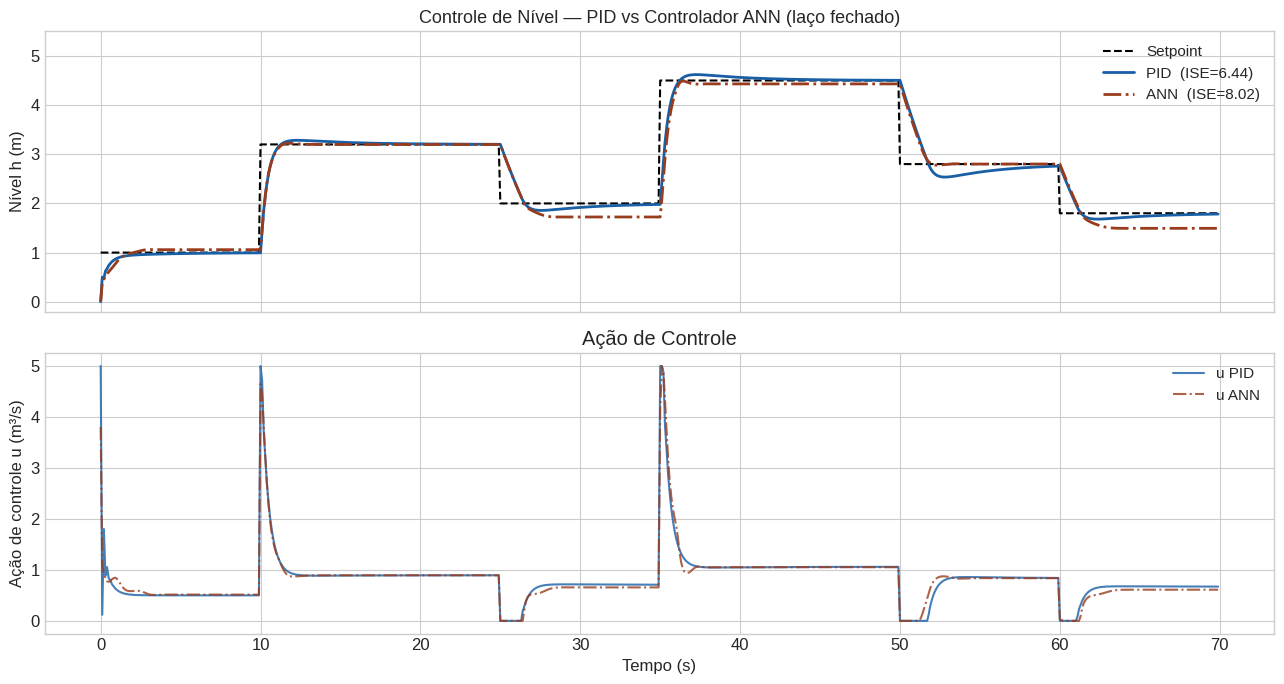

In [ ]:
# ============================================================
#  ETAPA 3: SIMULAÇÃO EM LAÇO FECHADO — PID vs ANN
# ============================================================

# Perfil de teste (setpoints NÃO vistos no treino)
setpoints_teste = (
    [1.0]*100 + [3.2]*150 + [2.0]*100 +
    [4.5]*150 + [2.8]*100 + [1.8]*100
)
T = len(setpoints_teste)

# --- Simulação com PID ---
h_pid = 0.0; integ_pid = 0.0; e_prev_pid = 0.0
hist_pid = {'h': [], 'u': [], 'r': []}

for r in setpoints_teste:
    e = r - h_pid
    integ_pid += e * dt
    deriv = (e - e_prev_pid) / dt
    u = np.clip(Kp*e + Ki*integ_pid + Kd*deriv, Umin, Umax)
    hist_pid['h'].append(h_pid)
    hist_pid['u'].append(u)
    hist_pid['r'].append(r)
    h_pid = planta(h_pid, u)
    e_prev_pid = e

# --- Simulação com ANN ---
h_ann = 0.0; e_prev_ann = 0.0
hist_ann = {'h': [], 'u': [], 'r': []}

for r in setpoints_teste:
    e = r - h_ann
    feat = scaler_ctrl.transform([[e, e_prev_ann, h_ann, r]])
    u    = float(np.clip(ann_ctrl.predict(feat)[0], Umin, Umax))
    hist_ann['h'].append(h_ann)
    hist_ann['u'].append(u)
    hist_ann['r'].append(r)
    h_ann = planta(h_ann, u)
    e_prev_ann = e

# --- Métricas ---
t = np.arange(T) * dt
r_arr = np.array(setpoints_teste)

ise_pid = np.sum((r_arr - np.array(hist_pid['h']))**2) * dt
ise_ann = np.sum((r_arr - np.array(hist_ann['h']))**2) * dt
print(f"ISE — PID: {ise_pid:.3f}   |   ANN: {ise_ann:.3f}")

# --- Visualização ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(t, hist_pid['r'], 'k--', lw=1.5, label='Setpoint')
ax1.plot(t, hist_pid['h'], color='#185FA5', lw=2,   label=f'PID  (ISE={ise_pid:.2f})')
ax1.plot(t, hist_ann['h'], color='#993C1D', lw=2,   label=f'ANN  (ISE={ise_ann:.2f})', ls='-.')
ax1.set_ylabel('Nível h (m)', fontsize=12)
ax1.set_title('Controle de Nível — PID vs Controlador ANN (laço fechado)', fontsize=13)
ax1.legend(fontsize=11); ax1.set_ylim(-0.2, 5.5)

ax2.plot(t, hist_pid['u'], color='#185FA5', lw=1.5, label='u PID',  alpha=0.8)
ax2.plot(t, hist_ann['u'], color='#993C1D', lw=1.5, label='u ANN', alpha=0.8, ls='-.')
ax2.set_ylabel('Ação de controle u (m³/s)', fontsize=12)
ax2.set_xlabel('Tempo (s)', fontsize=12)
ax2.set_title('Ação de Controle')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

## 3.4 Análise do Desempenho

### Métricas de desempenho em controle

| Métrica | Fórmula | Interpretação |
|---|---|---|
| **ISE** (Integral of Squared Error) | $\int e^2\, dt$ | Penaliza erros grandes |
| **IAE** (Integral of Absolute Error) | $\int |e|\, dt$ | Mais intuitivo |
| **Overshoot** | $\frac{y_{max} - r}{r} \times 100\%$ | Ultrapassagem do setpoint |
| **Tempo de assentamento** $t_s$ | Tempo para $|e| < 2\%$ | Velocidade de resposta |

### Observações

- O **controlador ANN** aprendeu a política do PID com alta fidelidade (R² ≈ 1)
- Em setpoints **não vistos** durante o treino, o desempenho ainda é satisfatório
- A diferença no ISE mostra que ANN pode ser ligeiramente diferente do PID original — isso é esperado

### Limitações da abordagem de imitação

- A ANN **não supera** o PID — apenas o imita
- Para regiões muito fora da distribuição de treino, pode ter extrapolação ruim
- Para melhorar: usar **Reinforcement Learning** (agente otimiza diretamente a recompensa)

In [ ]:
# ============================================================
#  ANÁLISE DETALHADA: Métricas e Resposta ao Degrau
# ============================================================

def calcular_metricas(h_arr, r_arr, dt=0.1):
    """Calcula ISE, IAE e tempo de assentamento (2%)."""
    e_arr = r_arr - h_arr
    ise   = np.sum(e_arr**2) * dt
    iae   = np.sum(np.abs(e_arr)) * dt

    # Tempo de assentamento (2%) — busca do último instante fora da banda
    banda = 0.02 * r_arr
    fora  = np.where(np.abs(e_arr) > banda)[0]
    ts    = fora[-1] * dt if len(fora) > 0 else 0.0

    return {'ISE': ise, 'IAE': iae, 't_s (s)': ts}

met_pid = calcular_metricas(np.array(hist_pid['h']), r_arr)
met_ann = calcular_metricas(np.array(hist_ann['h']), r_arr)

import pandas as pd
df_met = pd.DataFrame({'PID': met_pid, 'ANN': met_ann})
print("\n=== Comparação de Métricas ===")
print(df_met.round(3))

# --- Resposta ao degrau isolada ---
# Simular apenas um degrau: h(0)=0 → setpoint=3.0
N_step = 200
r_step = 3.0

# PID
h_p = 0.0; ig = 0.0; ep = 0.0; h_pid_step = []
for _ in range(N_step):
    e = r_step - h_p
    ig += e * dt
    u = np.clip(Kp*e + Ki*ig + Kd*(e-ep)/dt, Umin, Umax)
    h_pid_step.append(h_p); h_p = planta(h_p, u); ep = e

# ANN
h_a = 0.0; ea = 0.0; h_ann_step = []
for _ in range(N_step):
    e = r_step - h_a
    feat = scaler_ctrl.transform([[e, ea, h_a, r_step]])
    u = float(np.clip(ann_ctrl.predict(feat)[0], Umin, Umax))
    h_ann_step.append(h_a); h_a = planta(h_a, u); ea = e

t_step = np.arange(N_step) * dt
plt.figure(figsize=(10, 4))
plt.axhline(r_step, color='k', ls='--', lw=1.5, label=f'Setpoint = {r_step} m')
plt.axhspan(r_step*0.98, r_step*1.02, alpha=0.15, color='gray', label='Banda ±2%')
plt.plot(t_step, h_pid_step, color='#185FA5', lw=2, label='PID')
plt.plot(t_step, h_ann_step, color='#993C1D', lw=2, ls='-.', label='ANN')
plt.xlabel('Tempo (s)'); plt.ylabel('Nível h (m)')
plt.title('Resposta ao Degrau — PID vs ANN Controlador')
plt.legend(); plt.tight_layout(); plt.show()

---
# Conclusões e Próximos Passos

## O que aprendemos

1. **Neurônio artificial** → soma ponderada + ativação não-linear
2. **Backpropagation** → gradiente do erro propaga da saída para a entrada
3. **NARX** → ANN aprende a dinâmica de um processo a partir de dados de entrada/saída
4. **Behavioral Cloning** → ANN imita um controlador PID existente
5. **Laço fechado** → a ANN pode substituir o PID com desempenho comparável

## Próximos passos

### 🔷 Ferramentas
- **PyTorch / TensorFlow**: redes mais complexas, treinamento em GPU, backpropagation automático
- **LSTM / GRU**: redes recorrentes para séries temporais longas

### 🔷 Estratégias de controle avançadas
- **Neural MPC**: usar modelo NARX dentro de um controlador preditivo
- **ANN auto-tuning**: rede que ajusta $K_p$, $K_i$, $K_d$ do PID em tempo real
- **Reinforcement Learning (RL)**: agente aprende a política de controle por recompensa, sem dados supervisionados

### 🔷 Projeto de laboratório sugerido
1. Coletar dados de um processo real (planta didática, Arduino, simulador)
2. Identificar o modelo com NARX
3. Projetar um controlador ANN e comparar com PID
4. Avaliar robustez com perturbações

---
*Notebook desenvolvido para a disciplina de Controle e Automação de Processos.*